In [1]:
from pathlib import Path
import json

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parent
OBT  = ROOT / 'data' / 'gold' / 'obt.parquet'
OUT  = ROOT / 'data' / 'gold' / 'product_region_findings.json'

conn = duckdb.connect()
conn.execute(f"CREATE VIEW obt AS SELECT * FROM read_parquet('{OBT}')")

df = conn.execute('SELECT * FROM obt').df()
df['date'] = pd.to_datetime(df['date'])
df['year']    = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
df['month']   = df['date'].dt.month
df['etapa']   = df['date'].dt.day.apply(
    lambda d: 'Inicio' if d <= 10 else ('Meio' if d <= 20 else 'Fim')
)
df['periodo'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)

PRODUCTS = sorted(df['product'].unique())
REGIONS  = sorted(df['region'].unique())

print('Produtos:', PRODUCTS)
print('Regioes: ', REGIONS)
print('Periodo: ', df['date'].min().date(), '→', df['date'].max().date())
print('Linhas:  ', len(df))

Produtos: ['A', 'B', 'C']
Regioes:  ['APAC', 'EU', 'LATAM', 'NA']
Periodo:  2023-01-01 → 2024-12-31
Linhas:   8772


## 1. OTIF por produto × regiao

/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_62287/3023719202.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[df['total_pedidos'] > 0]


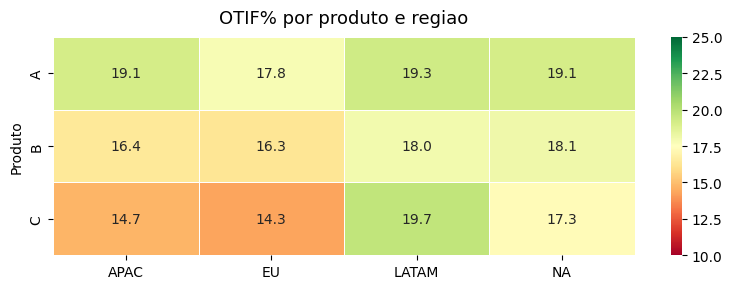

region   APAC    EU  LATAM    NA
product                         
A        19.1  17.8   19.3  19.1
B        16.4  16.3   18.0  18.1
C        14.7  14.3   19.7  17.3


In [2]:
otif_pr = (
    df[df['total_pedidos'] > 0]
    .groupby(['product', 'region'])
    .apply(lambda g: round(100 * g['pedidos_on_time'].sum() / g['total_pedidos'].sum(), 1))
    .unstack('region')
)

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    otif_pr, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=10, vmax=25, linewidths=0.5, ax=ax
)
ax.set_title('OTIF% por produto e regiao', fontsize=13, pad=10)
ax.set_xlabel('')
ax.set_ylabel('Produto')
plt.tight_layout()
plt.show()

print(otif_pr)

## 2. Stockout e overflow por produto × regiao

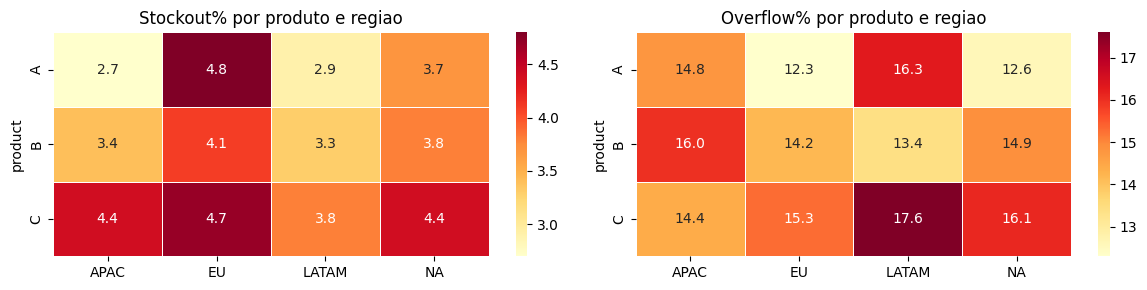

                pct_stockout  pct_overflow  dias_stockout  dias_overflow
product region                                                          
A       APAC             2.7          14.8             20            108
        EU               4.8          12.3             35             90
        LATAM            2.9          16.3             21            119
        NA               3.7          12.6             27             92
B       APAC             3.4          16.0             25            117
        EU               4.1          14.2             30            104
        LATAM            3.3          13.4             24             98
        NA               3.8          14.9             28            109
C       APAC             4.4          14.4             32            105
        EU               4.7          15.3             34            112
        LATAM            3.8          17.6             28            129
        NA               4.4          16.1         

In [3]:
flags = (
    df.groupby(['product', 'region'])
    .agg(
        pct_stockout=('stockout_flag', lambda x: round(100 * x.mean(), 1)),
        pct_overflow=('overflow_flag', lambda x: round(100 * x.mean(), 1)),
        dias_stockout=('stockout_flag', 'sum'),
        dias_overflow=('overflow_flag', 'sum'),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

sns.heatmap(
    flags['pct_stockout'].unstack('region'),
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Stockout% por produto e regiao')
axes[0].set_xlabel('')

sns.heatmap(
    flags['pct_overflow'].unstack('region'),
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Overflow% por produto e regiao')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print(flags)

## 3. Desequilibrio simultaneo: stockout numa regiao + overflow na outra (mesmo produto, mesmo dia)

Identifica dias em que o produto X esta em ruptura em uma regiao enquanto acumula excesso em outra.

In [4]:
imbalance_rows = []

for prod in PRODUCTS:
    dp = df[df['product'] == prod][['date', 'region', 'stockout_flag', 'overflow_flag', 'stock_level', 'periodo', 'quarter', 'month']].copy()
    stockout_regions  = dp[dp['stockout_flag']].set_index('date')['region']
    overflow_regions  = dp[dp['overflow_flag']].set_index('date')['region']

    common_dates = stockout_regions.index.intersection(overflow_regions.index)

    for date in common_dates:
        s_regions = stockout_regions[date]
        o_regions = overflow_regions[date]
        if isinstance(s_regions, str):
            s_regions = [s_regions]
        else:
            s_regions = list(s_regions)
        if isinstance(o_regions, str):
            o_regions = [o_regions]
        else:
            o_regions = list(o_regions)

        for sr in s_regions:
            for or_ in o_regions:
                if sr != or_:
                    row = dp[(dp['date'] == date) & (dp['region'] == or_)]
                    overflow_stock = int(row['stock_level'].iloc[0]) if len(row) else 0
                    imbalance_rows.append({
                        'date': date,
                        'product': prod,
                        'regiao_stockout': sr,
                        'regiao_overflow': or_,
                        'stock_overflow': overflow_stock,
                        'quarter': dp[dp['date'] == date]['quarter'].iloc[0],
                        'month':   dp[dp['date'] == date]['month'].iloc[0],
                        'periodo': dp[dp['date'] == date]['periodo'].iloc[0],
                    })

imbalance = pd.DataFrame(imbalance_rows)
print(f'Total de dias-par com desequilibrio simultaneo: {len(imbalance):,}')
print(imbalance.groupby(['product', 'regiao_stockout', 'regiao_overflow']).size().sort_values(ascending=False).to_string())

Total de dias-par com desequilibrio simultaneo: 139
product  regiao_stockout  regiao_overflow
C        EU               LATAM              8
B        EU               LATAM              8
C        EU               APAC               6
A        EU               APAC               6
C        LATAM            APAC               6
B        APAC             EU                 5
C        APAC             EU                 5
B        EU               APAC               5
C        NA               LATAM              5
                          APAC               5
A        APAC             NA                 5
C        LATAM            NA                 5
A        NA               LATAM              4
C        EU               NA                 4
         APAC             LATAM              4
A        APAC             LATAM              4
         NA               EU                 4
B        LATAM            NA                 4
         NA               APAC               4
             

## 4. Desequilibrio por trimestre e produto

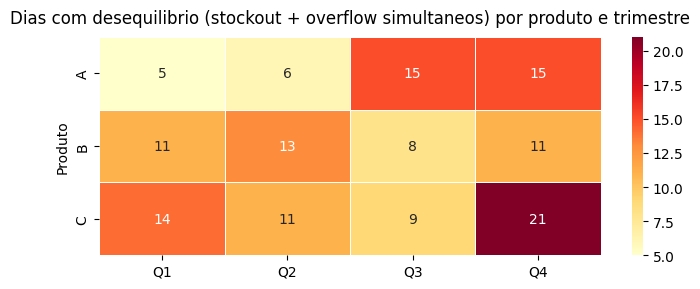

quarter  Q1  Q2  Q3  Q4
product                
A         5   6  15  15
B        11  13   8  11
C        14  11   9  21


In [5]:
imb_q = (
    imbalance
    .groupby(['product', 'quarter'])
    .size()
    .unstack('quarter')
    .rename(columns=lambda q: f'Q{q}')
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(
    imb_q, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=ax
)
ax.set_title('Dias com desequilibrio (stockout + overflow simultaneos) por produto e trimestre', pad=10)
ax.set_xlabel('')
ax.set_ylabel('Produto')
plt.tight_layout()
plt.show()

print(imb_q)

## 5. Pares de desequilibrio mais frequentes por produto

In [6]:
top_pairs = (
    imbalance
    .groupby(['product', 'regiao_stockout', 'regiao_overflow'])
    .agg(dias=('date', 'count'), stock_medio_overflow=('stock_overflow', 'mean'))
    .reset_index()
    .sort_values(['product', 'dias'], ascending=[True, False])
)
top_pairs['stock_medio_overflow'] = top_pairs['stock_medio_overflow'].round(0).astype(int)

print(top_pairs.to_string(index=False))

product regiao_stockout regiao_overflow  dias  stock_medio_overflow
      A              EU            APAC     6                 12382
      A            APAC              NA     5                 12393
      A            APAC           LATAM     4                 10800
      A              NA              EU     4                 12796
      A              NA           LATAM     4                 12121
      A              EU           LATAM     3                 11612
      A           LATAM              EU     3                 10153
      A           LATAM              NA     3                 13855
      A              NA            APAC     3                 12305
      A            APAC              EU     2                 10097
      A              EU              NA     2                 13402
      A           LATAM            APAC     2                 11354
      B              EU           LATAM     8                 11640
      B            APAC              EU     5   

## 6. Evolucao mensal do nivel de estoque por produto e regiao

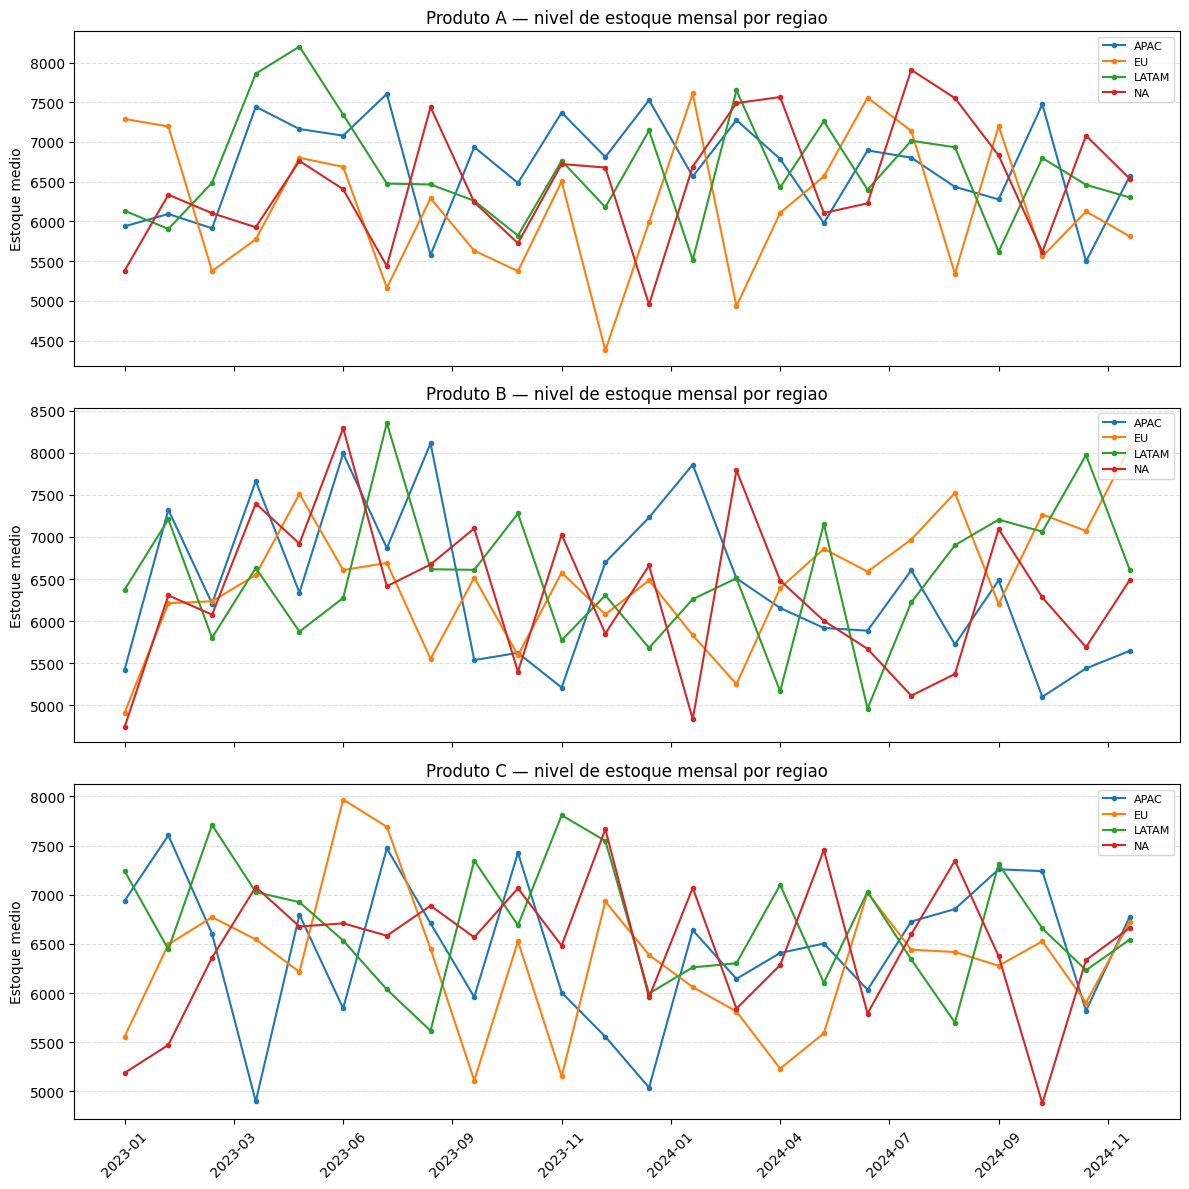

In [7]:
estoque_mensal = (
    df.assign(mes=df['date'].dt.to_period('M').astype(str))
    .groupby(['mes', 'product', 'region'])['stock_level']
    .mean().round(0).reset_index()
)

fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(12, 4 * len(PRODUCTS)), sharex=True)
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    dp = estoque_mensal[estoque_mensal['product'] == prod]
    for reg in REGIONS:
        dr = dp[dp['region'] == reg]
        ax.plot(dr['mes'], dr['stock_level'], marker='o', markersize=3, label=reg)
    ax.set_title(f'Produto {prod} — nivel de estoque mensal por regiao')
    ax.set_ylabel('Estoque medio')
    ax.legend(loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(12))

plt.tight_layout()
plt.show()

## 7. OTIF trimestral por produto e regiao

/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_62287/1096770696.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[df['total_pedidos'] > 0]
/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_62287/1096770696.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[df['total_pedidos'] > 0]


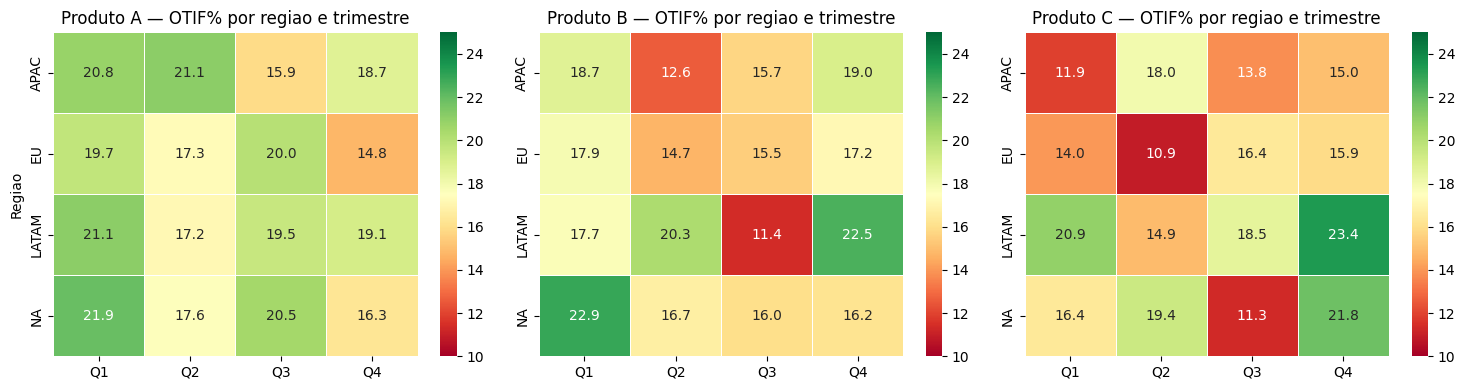

In [8]:
otif_pq = (
    df[df['total_pedidos'] > 0]
    .groupby(['product', 'periodo'])
    .apply(lambda g: round(100 * g['pedidos_on_time'].sum() / g['total_pedidos'].sum(), 1))
    .unstack('periodo')
)

otif_pr_q = (
    df[df['total_pedidos'] > 0]
    .assign(q='Q' + df['quarter'].astype(str))
    .groupby(['product', 'region', 'q'])
    .apply(lambda g: round(100 * g['pedidos_on_time'].sum() / g['total_pedidos'].sum(), 1))
    .reset_index(name='otif')
)

fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(5 * len(PRODUCTS), 4), sharey=False)
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    dp = otif_pr_q[otif_pr_q['product'] == prod].pivot(index='region', columns='q', values='otif')
    sns.heatmap(
        dp, annot=True, fmt='.1f', cmap='RdYlGn',
        vmin=10, vmax=25, linewidths=0.5, ax=ax
    )
    ax.set_title(f'Produto {prod} — OTIF% por regiao e trimestre')
    ax.set_xlabel('')
    ax.set_ylabel('Regiao' if prod == PRODUCTS[0] else '')

plt.tight_layout()
plt.show()

## 8. Correlacao entre estoque de regioes distintas (mesmo produto)

Correlacao negativa forte indica que quando uma regiao acumula, a outra resseca — evidencia de redistribuicao ineficiente.

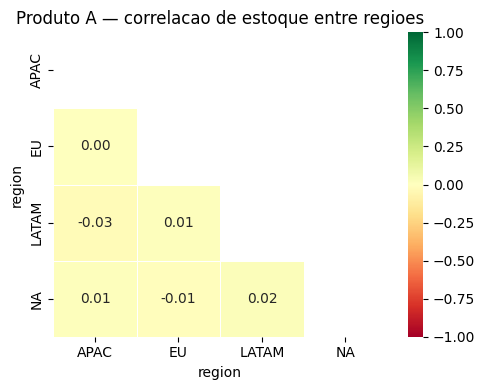

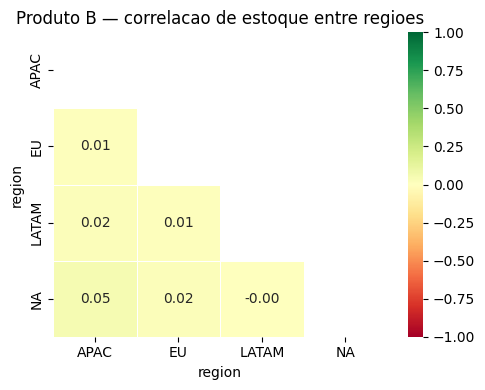

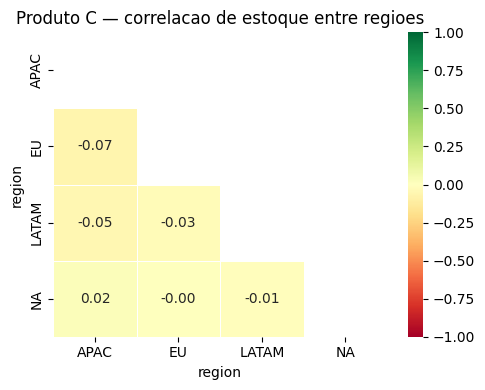

In [9]:
corr_findings = {}

for prod in PRODUCTS:
    pivot = (
        df[df['product'] == prod]
        .groupby(['date', 'region'])['stock_level']
        .mean()
        .unstack('region')
    )
    corr = pivot.corr().round(2)
    corr_findings[prod] = corr.to_dict()

    fig, ax = plt.subplots(figsize=(5, 4))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=-1, vmax=1, mask=mask, linewidths=0.5, ax=ax
    )
    ax.set_title(f'Produto {prod} — correlacao de estoque entre regioes')
    plt.tight_layout()
    plt.show()

## 9. Salvar achados em arquivo JSON

In [10]:
# OTIF global por produto x regiao
otif_dict = otif_pr.round(1).to_dict()

# Flags por produto x regiao
flags_dict = flags.reset_index().to_dict(orient='records')

# Top pares de desequilibrio
pairs_dict = top_pairs.to_dict(orient='records')

# Resumo de desequilibrio por produto x trimestre
imb_q_dict = imb_q.to_dict()

# Total de dias com desequilibrio por produto
imb_total = imbalance.groupby('product').size().to_dict()

# Produto + regiao com pior OTIF
otif_flat = otif_pr.stack().reset_index()
otif_flat.columns = ['product', 'region', 'otif']
worst_otif = otif_flat.loc[otif_flat['otif'].idxmin()]
best_otif  = otif_flat.loc[otif_flat['otif'].idxmax()]

findings = {
    'otif_por_produto_regiao': otif_dict,
    'stockout_overflow_por_produto_regiao': flags_dict,
    'top_pares_desequilibrio': pairs_dict,
    'desequilibrio_por_produto_trimestre': imb_q_dict,
    'total_dias_desequilibrio_por_produto': imb_total,
    'correlacao_estoque_entre_regioes': corr_findings,
    'pior_combinacao_otif': {
        'produto': worst_otif['product'],
        'regiao': worst_otif['region'],
        'otif': float(worst_otif['otif']),
    },
    'melhor_combinacao_otif': {
        'produto': best_otif['product'],
        'regiao': best_otif['region'],
        'otif': float(best_otif['otif']),
    },
}

with open(OUT, 'w', encoding='utf-8') as f:
    json.dump(findings, f, ensure_ascii=False, indent=2, default=str)

print(f'Achados salvos em: {OUT}')
print(f'\nPior OTIF:  Produto {worst_otif["product"]} / {worst_otif["region"]} = {worst_otif["otif"]}%')
print(f'Melhor OTIF: Produto {best_otif["product"]} / {best_otif["region"]} = {best_otif["otif"]}%')
print(f'\nTotal de dias-par com desequilibrio simultaneo: {len(imbalance):,}')
print('Por produto:')
for p, n in imb_total.items():
    print(f'  Produto {p}: {n:,} dias')

Achados salvos em: /Volumes/Apps SSD/Projects/personal/case-ball /data/gold/product_region_findings.json

Pior OTIF:  Produto C / EU = 14.3%
Melhor OTIF: Produto C / LATAM = 19.7%

Total de dias-par com desequilibrio simultaneo: 139
Por produto:
  Produto A: 41 dias
  Produto B: 43 dias
  Produto C: 55 dias
